In [1]:
from ultralytics import YOLO

# Cargar un modelo base (pequeño y rápido para prácticas)
model = YOLO('yolo11n.pt')

# Entrenar con tu dataset
results = model.train(
    data='datasets/data.yaml',  
    epochs=20,                            
    imgsz=640,                            
    project='runs'                       
)

New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.249 🚀 Python-3.13.5 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=N

In [17]:
model = YOLO('runs/train/weights/best.pt')

In [18]:
img_path = 'datasets/test/images/*.jpg'
resultados = model(img_path)

print(f"Objetos detectados inicialmente: {len(resultados[0].boxes)}")


image 1/80 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6.v2/datasets/test/images/Minor_bumper-sep27---18-_jpg.rf.4491b49559fa0a332f9255b831302498.jpg: 640x640 1 doorouter-dent, 5.7ms
image 2/80 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6.v2/datasets/test/images/Minor_bumper-sep27---82----Copy_jpg.rf.87f51b9e1f41f8831cd1573b1a65cf0e.jpg: 640x640 1 front-bumper-dent, 5.9ms
image 3/80 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6.v2/datasets/test/images/Minor_bumper-sep27---92----Copy_jpg.rf.1ce73c799a94f8c78e25ee4eb2348e1d.jpg: 640x640 1 fender-dent, 5.0ms
image 4/80 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6.v2/datasets/test/images/Minor_bumper-sep28---30-_jpg.rf.18d3e556fe4e49aac8d7918dc90dc129.jpg: 640x640 1 bonnet-dent, 1 fender-dent, 1 front-bumper-dent, 5.1ms
image 5/80 /home/ciabd01/Documentos/CEIABD/MIA/ConteodeObjetos_3.6.v2/datasets/test/images/akhand_b43_30_jpg.rf.520a80c97a74102f1bd7cb26909eb067.jpg: 640x640 1 doorouter-dent, 4.6m

In [19]:
from collections import Counter

UMBRAL_CONF = 0.4

prediccion = resultados[0]
cajas_totales = prediccion.boxes

boxes_filtradas = [box for box in cajas_totales if box.conf > UMBRAL_CONF]
print(f"Objetos reales tras filtrar (Confianza > {UMBRAL_CONF}): {len(boxes_filtradas)}")

ids_clases = [int(box.cls) for box in boxes_filtradas]
conteos = Counter(ids_clases)

print("\n REPORTE DE INVENTARIO:")
nombres_clases = model.names
for clase_id, cantidad in conteos.items():
    nombre_obj = nombres_clases[clase_id]
    print(f" -> {nombre_obj}: {cantidad} unidades")

Objetos reales tras filtrar (Confianza > 0.4): 1

 REPORTE DE INVENTARIO:
 -> doorouter-dent: 1 unidades


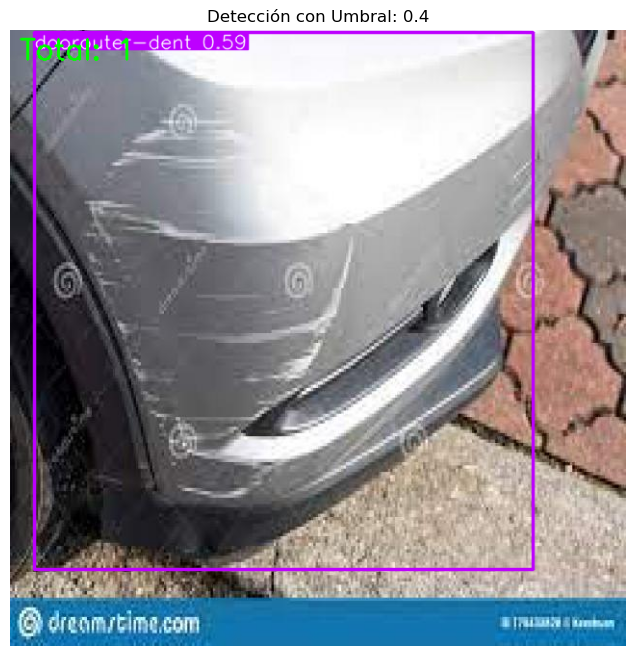

In [20]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

def visualizar_conteo(prediccion, boxes_filtradas, conteos, umbral):
    prediccion.boxes = prediccion.boxes[prediccion.boxes.conf > umbral]

    img_resultado = prediccion.plot()

    nombres = prediccion.names
    texto_conteo = ", ".join([f"{nombres[c]}: {n}" for c, n in conteos.items()])

    cv2.putText(img_resultado, f"Total: {len(boxes_filtradas)}", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img_resultado, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Detección con Umbral: {umbral}")
    plt.show()

visualizar_conteo(resultados[0], boxes_filtradas, conteos, UMBRAL_CONF)